# Bayesian Linear Regression with PyMC – Palmer Penguins Dataset

In this notebook, we analyze the relationship between penguin body mass and flipper length using both classical and Bayesian linear regression.

The analysis compares a classical OLS regression using `statsmodels` with Bayesian regression using `PyMC`.

We will also extend the analysis to a hierarchical regression model in order to examine differences between penguin species.

## 1. Setup and Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import pymc as pm
import arviz as az

In [2]:
penguins = sns.load_dataset("penguins")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
data = (
    penguins[
        ["species", "flipper_length_mm", "body_mass_g"]
    ]
    .dropna()
    .copy()
)

print("Original number of rows:", len(penguins))
print("Rows after removing missing values:", len(data))

print("\nObservations by species:")
print(data["species"].value_counts())

data.head()

Original number of rows: 344
Rows after removing missing values: 342

Observations by species:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


,species,flipper_length_mm,body_mass_g
0,Adelie,181.0,3750.0
1,Adelie,186.0,3800.0
2,Adelie,195.0,3250.0
4,Adelie,193.0,3450.0
5,Adelie,190.0,3650.0


## 2. Exploratory Data Analysis

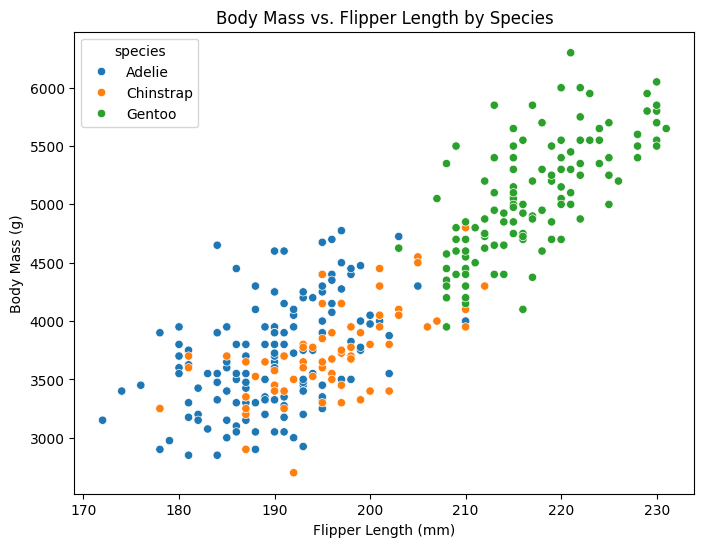

In [4]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass vs. Flipper Length by Species")

plt.show()

### Interpretation

There is a clear positive relationship between flipper length and body mass: penguins with longer flippers tend to have greater body mass.

However, the observations also form distinct clusters by species.

Gentoo penguins generally have longer flippers and higher body mass, while Adelie and Chinstrap penguins are concentrated at lower flipper lengths and body masses.

This suggests that species may explain part of the relationship between flipper length and body mass, so it will be useful to compare a single regression model with models that account for species differences.

## 3. Classical Linear Regression with Statsmodels

We first fit a classical ordinary least squares (OLS) regression model.

The response variable is body mass, and flipper length is used as the predictor.

To make the intercept easier to interpret and to prepare for the Bayesian model later, flipper length is centered around its sample mean.

### AI Question

**What assumptions does ordinary least squares regression make, how should the slope and intercept be interpreted, and what information should we examine in the OLS summary before trusting the model?**

In [5]:
data["flipper_centered"] = (
    data["flipper_length_mm"]
    - data["flipper_length_mm"].mean()
)

X = sm.add_constant(data["flipper_centered"])
y = data["body_mass_g"]

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          4.37e-107
Time:                        11:14:56   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             4201.7544     21.320  

### OLS Interpretation

The classical OLS model explains approximately 75.9% of the variability in body mass (\(R^2 = 0.759\)).

The estimated slope is approximately 49.69, meaning that an increase of 1 mm in flipper length is associated with an average increase of about 49.7 g in body mass.

The slope is statistically significant, with a very small p-value and a 95% confidence interval of approximately [46.70, 52.67].

Because flipper length was centered around its sample mean, the intercept of approximately 4201.75 g represents the predicted body mass for a penguin with an average flipper length.

Although the overall fit is strong, the OLS summary alone is not enough to validate the model assumptions. Residual diagnostics are examined next.

### Residual Diagnostics

Residual diagnostics are used to examine whether the assumptions of the linear regression model are reasonable.

### AI Question

**What should we look for in residual plots, and how can residual patterns or departures from normality indicate problems with a linear regression model?**

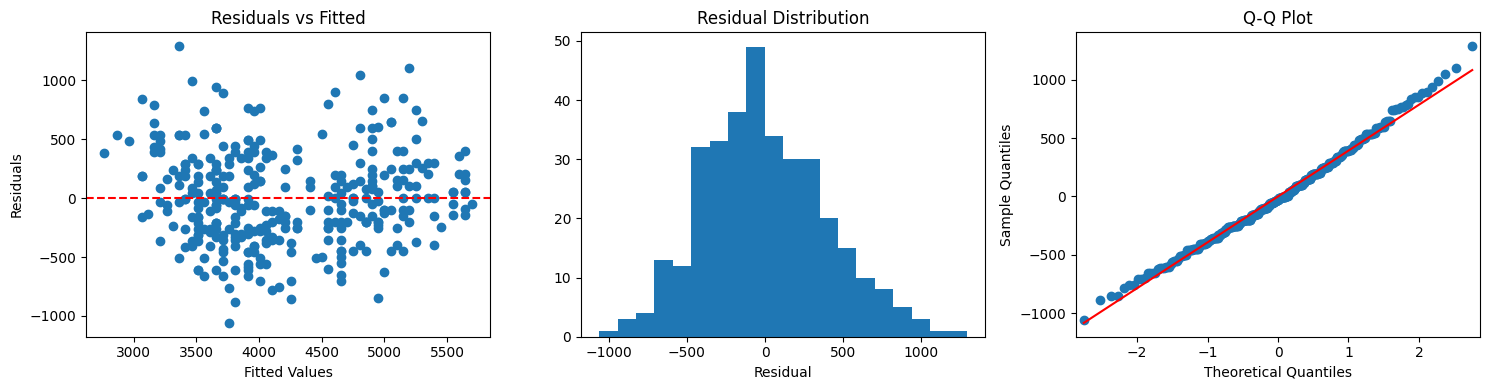

In [6]:
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(fitted_values, residuals)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=20)
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

sm.graphics.qqplot(
    residuals,
    line="s",
    ax=axes[2]
)
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

### Residual Diagnostics – Interpretation

The residuals are centered approximately around zero, but the residuals-versus-fitted plot shows visible structure rather than a completely random cloud.

This suggests that a single regression line may not capture all systematic variation in body mass.

The residual histogram is approximately symmetric, and the Q-Q plot follows the reference line reasonably well through most of the distribution, although some deviations appear in the tails.

A likely source of the remaining structure is species, which was already seen in the exploratory analysis to form distinct groups.

Therefore, the next classical model will include species information before we compare it with a Bayesian hierarchical regression.

### Classical Regression with Species

The previous OLS model used a single regression line for all penguins.

We now include species using dummy variables and interactions with flipper length. This allows both the intercept and the slope to differ across species.

Adelie is used as the reference category.

### AI Question

**Why do we omit one category when using dummy variables in a regression model, and what does an interaction between species and flipper length allow us to estimate?**

In [7]:
species_dummies = pd.get_dummies(
    data["species"],
    drop_first=True,
    dtype=float
)

X_species = pd.DataFrame({
    "const": 1.0,
    "flipper_centered": data["flipper_centered"],
    "Chinstrap": species_dummies["Chinstrap"],
    "Gentoo": species_dummies["Gentoo"],
    "flipper_x_Chinstrap":
        data["flipper_centered"] * species_dummies["Chinstrap"],
    "flipper_x_Gentoo":
        data["flipper_centered"] * species_dummies["Gentoo"]
})

ols_species = sm.OLS(
    data["body_mass_g"],
    X_species
).fit()

print(ols_species.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     252.2
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          2.22e-111
Time:                        11:22:17   Log-Likelihood:                -2505.2
No. Observations:                 342   AIC:                             5022.
Df Residuals:                     336   BIC:                             5045.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4060.5489    

### Species Model – Interpretation

Including species and species-by-flipper-length interactions improves the model fit, increasing \(R^2\) from approximately 0.759 to 0.790.

For the reference species, Adelie, the estimated slope is approximately 32.83 g per additional millimeter of flipper length.

The Chinstrap interaction is small and not statistically significant (\(p = 0.825\)), suggesting that its slope is not clearly different from the Adelie slope.

The Gentoo interaction is approximately 21.79 and is statistically significant (\(p = 0.002\)). Therefore, the estimated Gentoo slope is approximately \(32.83 + 21.79 = 54.62\) g per millimeter.

The species coefficients represent differences in predicted body mass relative to Adelie when flipper length is at the centered value, which corresponds to the overall sample mean.

This model suggests that allowing relationships to differ across species captures additional structure that was missed by the single regression line.

### Residual Diagnostics for the Species Model

We now examine the residuals of the model that includes species and interaction terms.

The goal is to check whether accounting for species reduces systematic structure in the residuals compared with the simpler OLS model.

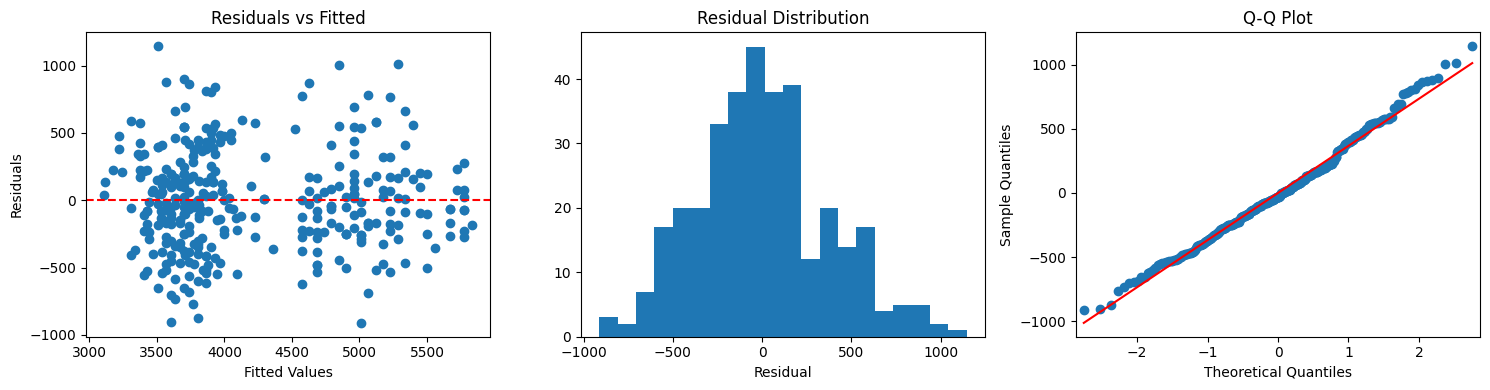

In [8]:
species_residuals = ols_species.resid
species_fitted = ols_species.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(species_fitted, species_residuals)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(species_residuals, bins=20)
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

sm.graphics.qqplot(
    species_residuals,
    line="s",
    ax=axes[2]
)
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

### Species Model Residuals – Interpretation

Including species and interaction terms improves the overall regression fit, but the residuals are still not completely random.

The residuals-versus-fitted plot continues to show some structure and variation in spread across the fitted values, suggesting that the model does not capture all remaining variability.

The residual distribution is approximately symmetric, and the Q-Q plot follows the reference line reasonably well through most of the distribution, with some deviations in the tails.

Therefore, including species improves the classical model, but some model assumptions are still only approximately satisfied.

## 4. Bayesian Linear Regression with PyMC

We now fit a Bayesian version of the simple linear regression model.

The predictor is centered flipper length, and the response variable is body mass.

The model estimates posterior distributions for the intercept, slope, and residual standard deviation.

### AI Question

**How does Bayesian linear regression differ from classical OLS, and how should prior distributions for the intercept, slope, and residual standard deviation be interpreted?**

Output()

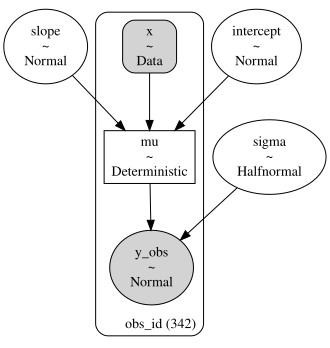

In [9]:
coords = {"obs_id": np.arange(len(data))}

with pm.Model(coords=coords) as bayesian_regression:

    intercept = pm.Normal(
        "intercept",
        mu=4200,
        sigma=1000
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=100
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1000
    )

    x = pm.Data(
        "x",
        data["flipper_centered"].values,
        dims="obs_id"
    )

    mu = pm.Deterministic(
        "mu",
        intercept + slope * x,
        dims="obs_id"
    )

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=data["body_mass_g"].values,
        dims="obs_id"
    )

    idata_bayes = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

pm.model_to_graphviz(bayesian_regression)

In [10]:
az.summary(
    idata_bayes,
    var_names=["intercept", "slope", "sigma"],
    hdi_prob=0.95
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,4201.764,21.151,4160.485,4242.917,0.197,0.224,11491.0,6153.0,1.0
slope,49.656,1.523,46.700,52.620,0.014,0.017,11498.0,5953.0,1.0
sigma,395.414,15.187,365.582,424.698,0.138,0.180,12076.0,5715.0,1.0


### Bayesian Regression – Interpretation

The Bayesian posterior estimates are very similar to the classical OLS estimates.

The posterior mean of the intercept is approximately 4201.76 g, compared with approximately 4201.75 g in the OLS model.

The posterior mean of the slope is approximately 49.66 g per millimeter, compared with approximately 49.69 g in the OLS model.

The 95% HDI for the slope is approximately [46.70, 52.62], which is also very similar to the classical 95% confidence interval.

The residual standard deviation is estimated at approximately 395 g.

The MCMC diagnostics are also satisfactory: all `r_hat` values are 1.00 and the effective sample sizes are high, suggesting good convergence and efficient sampling.

Although the numerical estimates are very similar, the interpretations differ: the Bayesian model provides posterior probability distributions for the parameters, while the classical model reports sampling-based estimates and confidence intervals.

### Posterior Distributions and Trace Plots

Posterior plots summarize the uncertainty in the regression parameters.

Trace plots are used to visually assess MCMC convergence and mixing across chains.

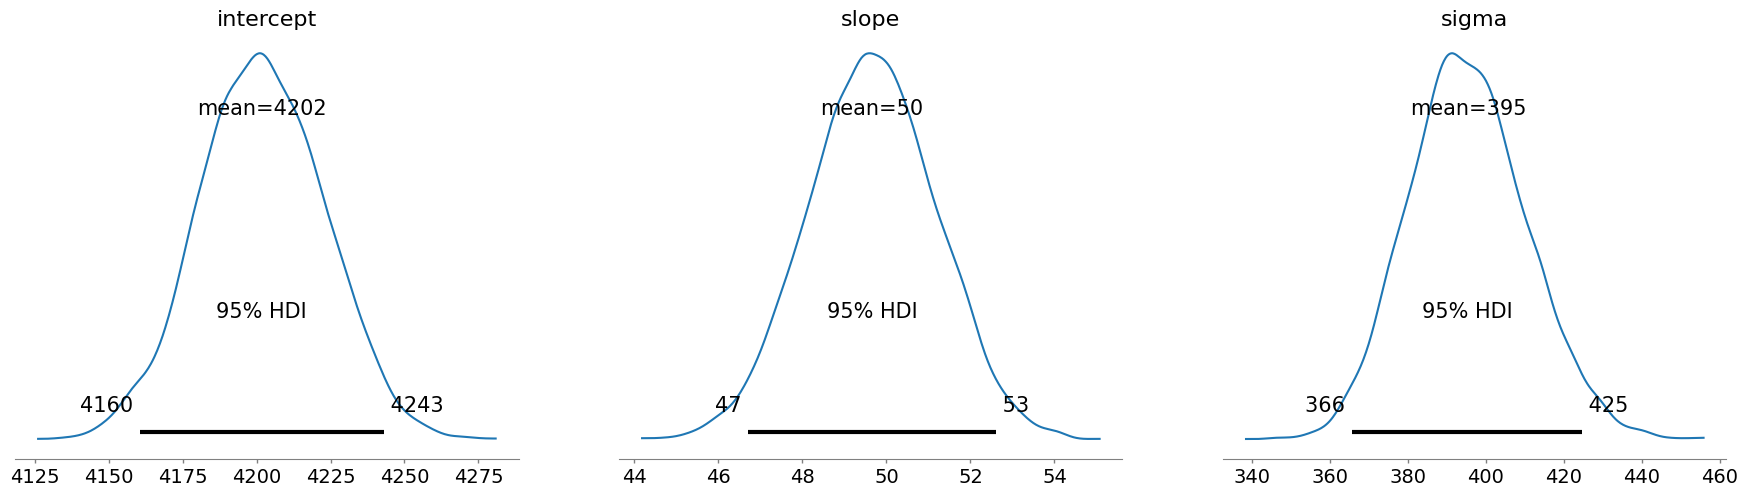

In [11]:
az.plot_posterior(
    idata_bayes,
    var_names=["intercept", "slope", "sigma"],
    hdi_prob=0.95
)

plt.show()

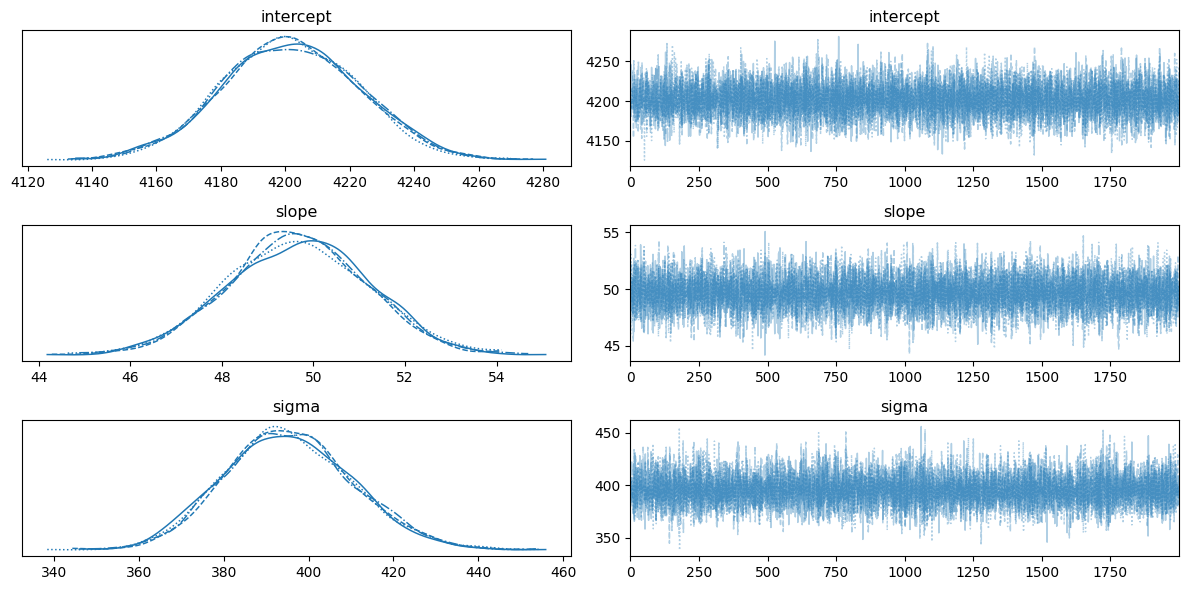

In [12]:
az.plot_trace(
    idata_bayes,
    var_names=["intercept", "slope", "sigma"]
)

plt.tight_layout()
plt.show()

### Posterior and Trace Plot – Interpretation

The posterior distributions for the intercept, slope, and residual standard deviation are smooth and concentrated around their posterior means.

The trace plots show that the four MCMC chains overlap and mix well, with no visible trends or systematic separation between chains.

Together with the \(r\_hat\) values of 1.00 and the high effective sample sizes, these plots provide additional evidence that the MCMC sampling converged successfully.

The posterior for the slope is clearly concentrated above zero, supporting a positive relationship between flipper length and body mass.

### Posterior Predictive Distribution

Posterior predictive sampling allows us to generate possible new body-mass observations using the uncertainty in the posterior distributions of the regression parameters.

### AI Question

**What is the difference between the posterior distribution of the regression parameters and the posterior predictive distribution? Why can it be useful to separate an inference model from a predictive model, and is this separation required? Why does `pm.sample_posterior_predictive()` not produce MCMC diagnostics like `pm.sample()`? How can deterministic quantities such as the regression mean be generated from posterior draws without running MCMC again?**

Output()

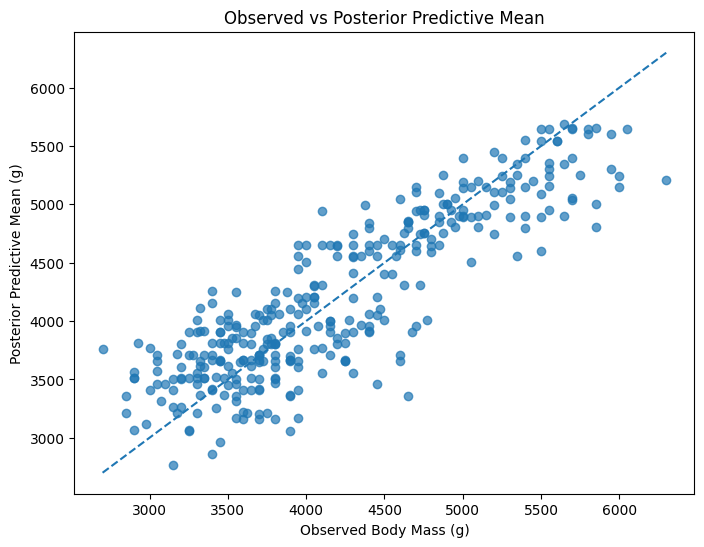

In [13]:
with bayesian_regression:
    posterior_predictive = pm.sample_posterior_predictive(
        idata_bayes,
        var_names=["mu", "y_obs"],
        random_seed=42
    )

predicted_mean = (
    posterior_predictive.posterior_predictive["y_obs"]
    .mean(dim=("chain", "draw"))
    .values
)

plt.figure(figsize=(8, 6))

plt.scatter(
    data["body_mass_g"],
    predicted_mean,
    alpha=0.7
)

min_value = min(
    data["body_mass_g"].min(),
    predicted_mean.min()
)

max_value = max(
    data["body_mass_g"].max(),
    predicted_mean.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Observed Body Mass (g)")
plt.ylabel("Posterior Predictive Mean (g)")
plt.title("Observed vs Posterior Predictive Mean")

plt.show()

### Posterior Predictive – Interpretation

The posterior predictive mean follows the overall pattern of the observed body masses reasonably well.

However, the predictions do not lie perfectly on the 45-degree reference line. Very low observed body masses tend to be predicted somewhat higher, while very high observed body masses tend to be predicted somewhat lower.

This indicates that the simple Bayesian regression captures the general relationship between flipper length and body mass, but it does not capture all of the structure in the data.

One likely reason is that the model uses a single regression line for all penguin species, even though the exploratory analysis showed clear differences between species.

It is also important to note that this plot shows the posterior predictive mean. Averaging the predictive samples hides the full predictive uncertainty, so this plot should not be interpreted as a complete posterior predictive check.

### MCMC Diagnostics

PyMC uses NUTS, an adaptive form of Hamiltonian Monte Carlo, for continuous parameters in this model.

### AI Question

**How does random-walk Metropolis-Hastings with a Gaussian proposal differ from HMC and NUTS? What can go wrong when the proposal scale is poorly chosen, how do HMC and NUTS use gradients of the log posterior, and what changes when a Bayesian model contains discrete parameters? Also, how should divergences, `r_hat`, `ess_bulk`, `ess_tail`, and MCSE be used together when evaluating MCMC convergence?**

Number of divergences: 0


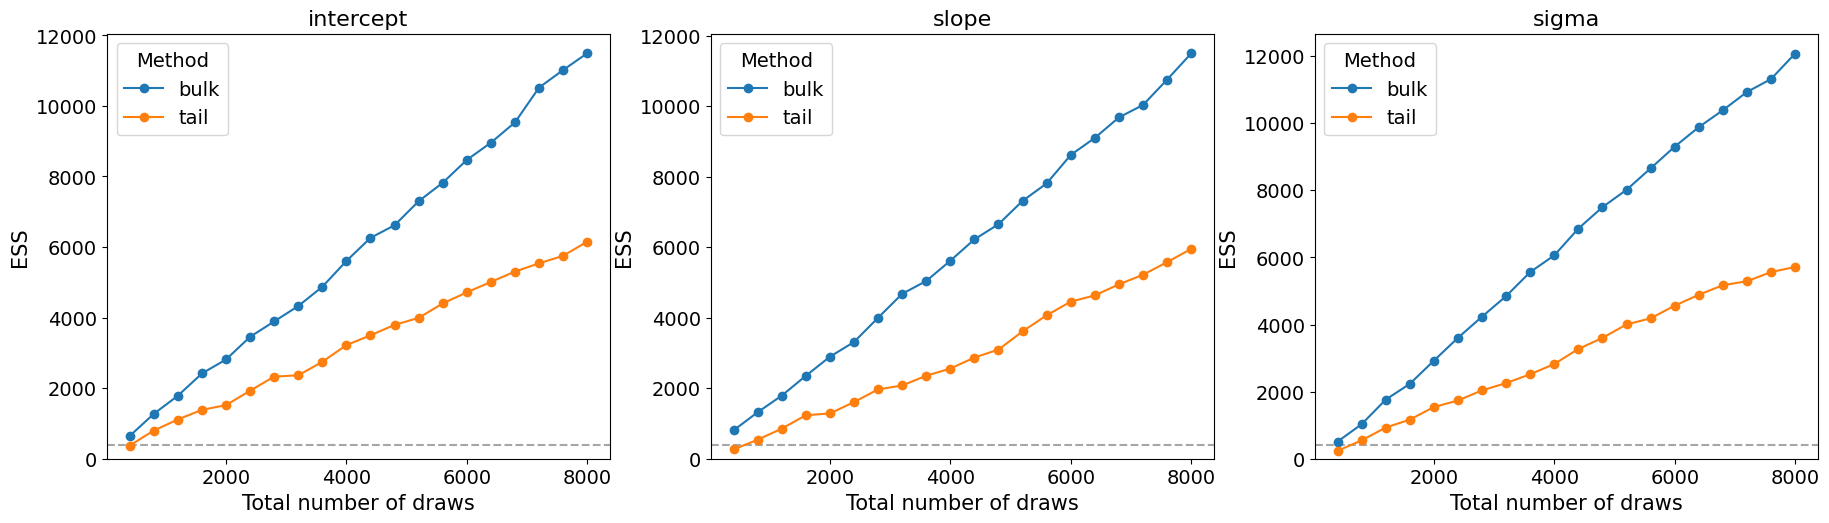

In [14]:
n_divergences = int(
    idata_bayes.sample_stats["diverging"].sum().values
)

print("Number of divergences:", n_divergences)

az.plot_ess(
    idata_bayes,
    var_names=["intercept", "slope", "sigma"],
    kind="evolution"
)

plt.show()

### MCMC Diagnostics – Interpretation

The model produced zero divergences, indicating that NUTS was able to explore the posterior distribution without obvious sampling pathologies.

The effective sample size increases steadily as more draws are accumulated.

Both `ess_bulk` and `ess_tail` are high, indicating that the sampler provides a large number of effectively independent draws from both the central and tail regions of the posterior.

Together with the previous `r_hat` values of 1.00 and the well-mixed trace plots, these diagnostics suggest that the Bayesian regression model converged successfully.

### Joint Posterior of the Intercept and Slope

Marginal posterior plots show the uncertainty of each parameter separately.

The joint posterior allows us to examine whether the intercept and slope are related in the posterior distribution.

### AI Question

**Why is it useful to examine the joint posterior distribution of the intercept and slope, how does MCMC approximate this joint distribution, and what does the KDE in a joint posterior plot represent?**

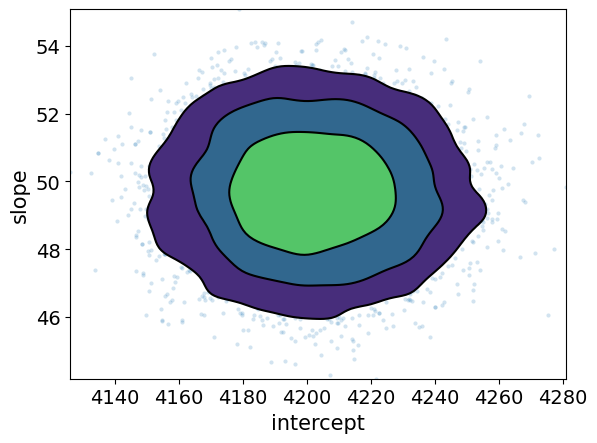

In [15]:
az.plot_pair(
    idata_bayes,
    var_names=["intercept", "slope"],
    kind=["kde", "scatter"],
    scatter_kwargs={"alpha": 0.2}
)

plt.show()

### Joint Posterior – Interpretation

The joint posterior is concentrated around an intercept of approximately 4200 g and a slope of approximately 50 g per millimeter.

The contours are fairly compact and do not show a strong diagonal pattern, suggesting that the posterior dependence between the intercept and slope is relatively weak.

Centering flipper length around its mean helps reduce posterior correlation between the intercept and slope.

The KDE contours provide a smoothed estimate of the joint posterior density, with the inner regions representing combinations of parameter values with higher posterior density.

### Grid Approximation of the Joint Posterior

The joint posterior of the intercept and slope can also be approximated without MCMC by evaluating the posterior density over a fixed grid of parameter values.

For this two-dimensional illustration, the residual standard deviation is fixed at its posterior mean from the PyMC model.

### AI Question

**How does the grid method approximate a posterior distribution without MCMC, why does it become impractical as the number of parameters increases, and why can multiplying many likelihood values directly cause numerical underflow?**

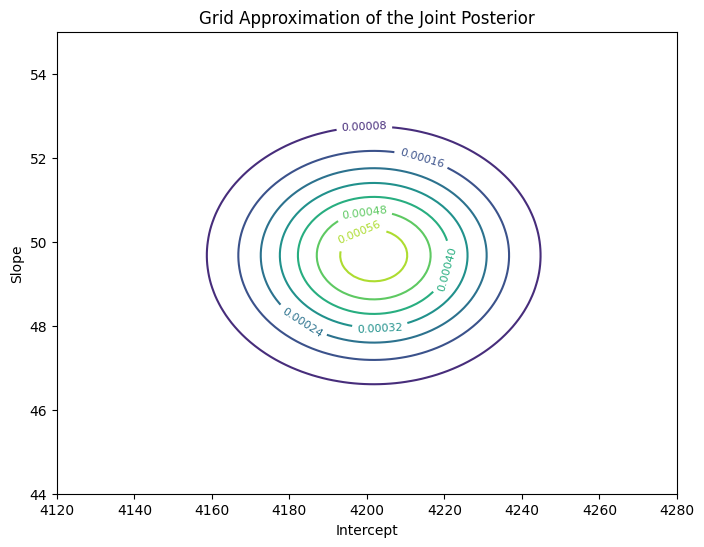

In [16]:
from scipy import stats

n_grid = 120

intercept_grid = np.linspace(4120, 4280, n_grid)
slope_grid = np.linspace(44, 55, n_grid)

sigma_fixed = float(
    idata_bayes.posterior["sigma"].mean().values
)

x_values = data["flipper_centered"].values
y_values = data["body_mass_g"].values

log_posterior = np.empty((n_grid, n_grid))

for i, intercept_value in enumerate(intercept_grid):
    for j, slope_value in enumerate(slope_grid):

        mu_grid = (
            intercept_value
            + slope_value * x_values
        )

        log_prior_intercept = stats.norm.logpdf(
            intercept_value,
            loc=4200,
            scale=1000
        )

        log_prior_slope = stats.norm.logpdf(
            slope_value,
            loc=0,
            scale=100
        )

        log_likelihood = stats.norm.logpdf(
            y_values,
            loc=mu_grid,
            scale=sigma_fixed
        ).sum()

        log_posterior[i, j] = (
            log_prior_intercept
            + log_prior_slope
            + log_likelihood
        )

posterior_grid = np.exp(
    log_posterior - log_posterior.max()
)

posterior_grid /= posterior_grid.sum()

S, I = np.meshgrid(
    slope_grid,
    intercept_grid
)

plt.figure(figsize=(8, 6))

contour = plt.contour(
    I,
    S,
    posterior_grid,
    levels=8
)

plt.clabel(contour, inline=True, fontsize=8)

plt.xlabel("Intercept")
plt.ylabel("Slope")
plt.title("Grid Approximation of the Joint Posterior")

plt.show()

### Grid Approximation – Interpretation

The grid approximation produces a joint posterior concentrated around an intercept of approximately 4200 g and a slope of approximately 50 g per millimeter.

This is very similar to the joint posterior obtained from the MCMC samples.

The agreement between the two approaches provides an additional validation of the Bayesian regression results.

The grid method is practical here because only two parameters are varied. However, the number of grid points grows rapidly as more parameters are added, making the method computationally inefficient in higher-dimensional models.

Using log-probabilities also avoids numerical underflow that can occur when multiplying many very small likelihood values directly.

### Bayesian Regression Line and Predictive Uncertainty

The posterior distribution allows us to distinguish between uncertainty about the mean regression function and uncertainty about future observations.

The interval around the regression line reflects uncertainty in the estimated mean relationship.

The posterior predictive interval is wider because it also includes the residual variability of individual observations.

### AI Question

**What is the difference between a 95% HDI for the mean regression function and a 95% posterior predictive interval for individual future observations, and why is the posterior predictive interval usually wider?**

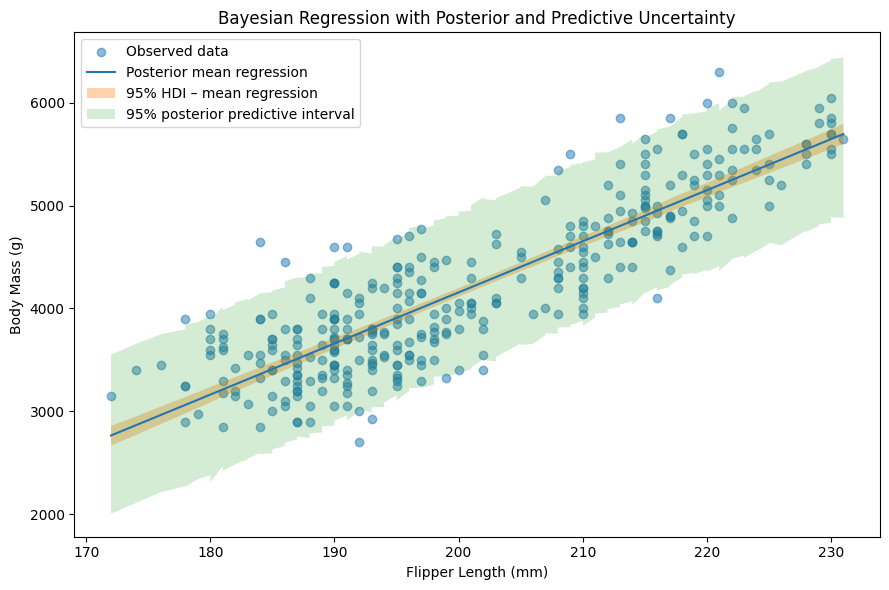

In [17]:
order = np.argsort(data["flipper_length_mm"].values)

x_plot = data["flipper_length_mm"].values[order]
y_plot = data["body_mass_g"].values[order]

mu_draws = posterior_predictive.posterior_predictive["mu"]
y_pred_draws = posterior_predictive.posterior_predictive["y_obs"]

mu_mean = (
    mu_draws
    .mean(dim=("chain", "draw"))
    .values[order]
)

mu_hdi = (
    az.hdi(mu_draws, hdi_prob=0.95)["mu"]
    .values[order]
)

pred_hdi = (
    az.hdi(y_pred_draws, hdi_prob=0.95)["y_obs"]
    .values[order]
)

plt.figure(figsize=(9, 6))

plt.scatter(
    x_plot,
    y_plot,
    alpha=0.5,
    label="Observed data"
)

plt.plot(
    x_plot,
    mu_mean,
    label="Posterior mean regression"
)

plt.fill_between(
    x_plot,
    mu_hdi[:, 0],
    mu_hdi[:, 1],
    alpha=0.35,
    label="95% HDI – mean regression"
)

plt.fill_between(
    x_plot,
    pred_hdi[:, 0],
    pred_hdi[:, 1],
    alpha=0.20,
    label="95% posterior predictive interval"
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Bayesian Regression with Posterior and Predictive Uncertainty")

plt.legend()
plt.tight_layout()
plt.show()

### Bayesian Regression with Uncertainty – Interpretation

The posterior mean regression line shows the estimated average relationship between flipper length and body mass.

The 95% HDI around the regression line reflects uncertainty about the mean regression function.

The 95% posterior predictive interval is wider because it reflects both uncertainty in the regression parameters and the residual variability of individual observations.

The plot shows a clear positive relationship: penguins with longer flippers tend to have higher body mass.

### Group Structure and Simpson's Paradox

When data from different groups are combined, the overall relationship between two variables can differ from the relationships observed within the individual groups.

This phenomenon is related to Simpson's paradox and highlights the importance of considering relevant grouping variables before interpreting an aggregate regression.

In the Palmer Penguins data, species form clearly different groups, and the relationship between flipper length and body mass is not identical across species.

The results here do not necessarily show a classic reversal of the relationship, so we should not claim that a full Simpson's paradox occurs. However, the strong species structure shows why an aggregate regression alone may hide important group-level differences.

### AI Question

**What is Simpson's paradox, how can aggregation across groups produce a misleading relationship, and does the Palmer Penguins analysis here provide evidence of a full Simpson's paradox or mainly of important group-level heterogeneity?**

## 5. Hierarchical Bayesian Regression by Species

The previous Bayesian model used a single intercept and slope for all penguins.

We now allow each species to have its own intercept and slope while assuming that the species-specific parameters come from shared population-level distributions.

This hierarchical structure allows partial pooling: information is shared across species while still allowing species-specific relationships.

### AI Question

**What is hierarchical regression, what are hyperpriors, and how does partial pooling differ from fitting completely separate regressions for each species? When can partial pooling be useful, and when can the assumption of shared group-level distributions be questionable?**


In [18]:
species_names = ["Adelie", "Chinstrap", "Gentoo"]

data["species"] = pd.Categorical(
    data["species"],
    categories=species_names
)

species_idx = data["species"].cat.codes.values

coords_h = {
    "species": species_names,
    "obs_id": np.arange(len(data))
}

print("Species:", species_names)
print("\nGroup codes:")
print(data[["species"]].assign(species_idx=species_idx).head(10))

Species: ['Adelie', 'Chinstrap', 'Gentoo']

Group codes:
   species  species_idx
0   Adelie            0
1   Adelie            0
2   Adelie            0
4   Adelie            0
5   Adelie            0
6   Adelie            0
7   Adelie            0
8   Adelie            0
9   Adelie            0
10  Adelie            0


### Centered Hierarchical Model

In the centered hierarchical model, each species has its own intercept and slope.

The species-specific parameters are drawn directly from shared population-level distributions.

This allows the model to estimate differences between species while sharing information across groups.

Output()

ERROR:pymc.stats.convergence:There were 351 divergences after tuning. Increase `target_accept` or reparameterize.


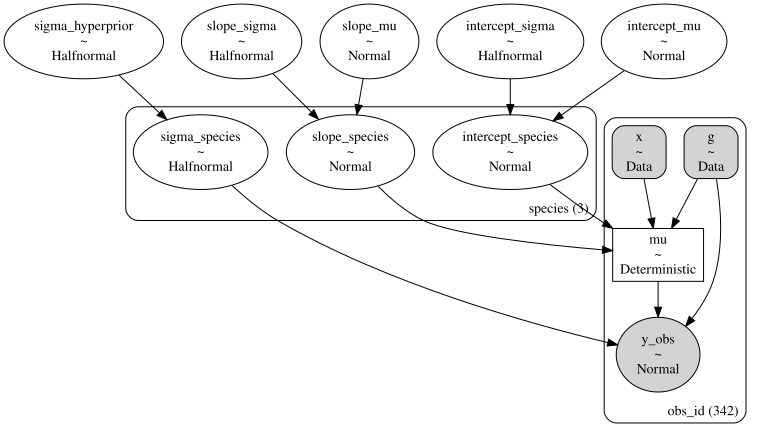

In [19]:
with pm.Model(coords=coords_h) as hierarchical_centered:

    # Hyperpriors
    intercept_mu = pm.Normal(
        "intercept_mu",
        mu=4200,
        sigma=1000
    )

    intercept_sigma = pm.HalfNormal(
        "intercept_sigma",
        sigma=1000
    )

    slope_mu = pm.Normal(
        "slope_mu",
        mu=50,
        sigma=50
    )

    slope_sigma = pm.HalfNormal(
        "slope_sigma",
        sigma=50
    )

    sigma_hyperprior = pm.HalfNormal(
        "sigma_hyperprior",
        sigma=1000
    )

    # Species-specific parameters
    intercept_species = pm.Normal(
        "intercept_species",
        mu=intercept_mu,
        sigma=intercept_sigma,
        dims="species"
    )

    slope_species = pm.Normal(
        "slope_species",
        mu=slope_mu,
        sigma=slope_sigma,
        dims="species"
    )

    sigma_species = pm.HalfNormal(
        "sigma_species",
        sigma=sigma_hyperprior,
        dims="species"
    )

    # Data
    x = pm.Data(
        "x",
        data["flipper_centered"].values,
        dims="obs_id"
    )

    g = pm.Data(
        "g",
        species_idx,
        dims="obs_id"
    )

    # Linear model
    mu = pm.Deterministic(
        "mu",
        intercept_species[g] + slope_species[g] * x,
        dims="obs_id"
    )

    pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma_species[g],
        observed=data["body_mass_g"].values,
        dims="obs_id"
    )

    idata_centered = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

pm.model_to_graphviz(hierarchical_centered)

### Centered Model – Initial Diagnostic

The centered hierarchical model produced 351 divergences after tuning.

This is a serious MCMC warning and indicates that NUTS had difficulty exploring some regions of the posterior distribution.

Therefore, the posterior estimates from this model should not be interpreted as fully reliable yet.

### AI Question

**Should we worry about hundreds of divergences in a hierarchical Bayesian model? What can divergences tell us about the posterior geometry, and why can hierarchical models be especially difficult for HMC and NUTS to sample using a centered parameterization?**

### Centered Model – Trace Diagnostics

We first inspect the trace plots of the population-level parameters.

Poor mixing, chain separation, or long periods in which a chain becomes stuck can indicate that the centered parameterization is difficult for the sampler to explore.

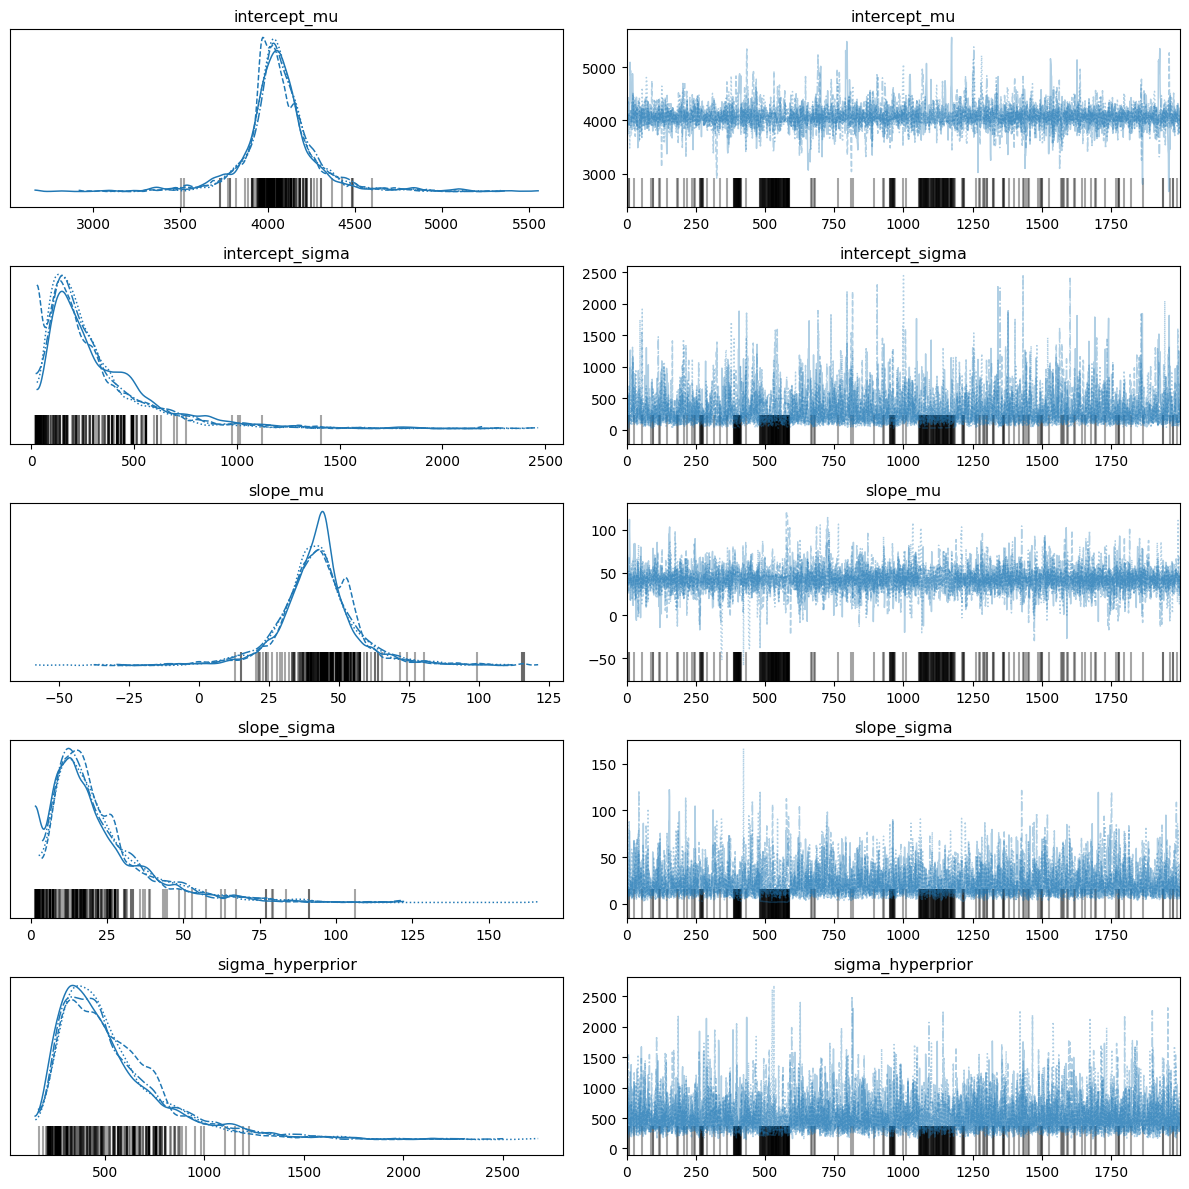

In [20]:
az.plot_trace(
    idata_centered,
    var_names=[
        "intercept_mu",
        "intercept_sigma",
        "slope_mu",
        "slope_sigma",
        "sigma_hyperprior"
    ],
    figsize=(12, 12)
)

plt.tight_layout()
plt.show()

### Trace Diagnostics – Interpretation

The chains generally explore similar regions, but the scale parameters show highly skewed posterior distributions and occasional large excursions.

In particular, `intercept_sigma`, `slope_sigma`, and `sigma_hyperprior` have long right tails and unstable-looking traces.

Together with the 351 divergences, this suggests that the centered hierarchical parameterization creates difficult posterior geometry for NUTS.

We therefore examine additional diagnostics before reparameterizing the model.

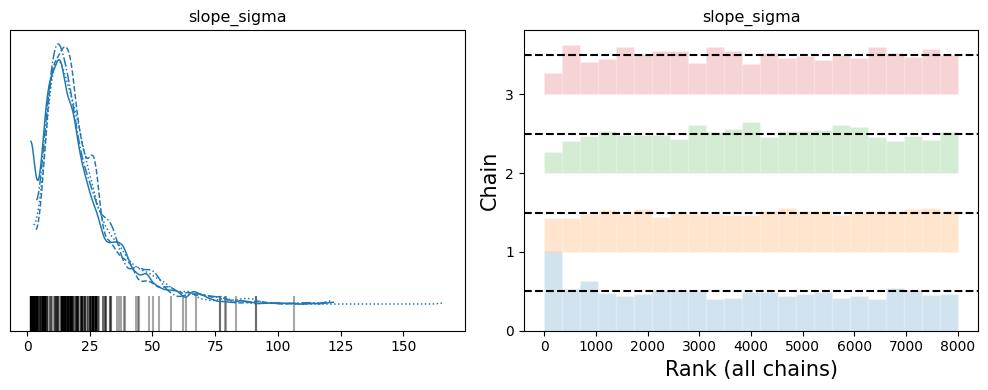

In [21]:
az.plot_trace(
    idata_centered,
    var_names=["slope_sigma"],
    kind="rank_bars",
    figsize=(10, 4)
)

plt.tight_layout()
plt.show()

### Rank Plot – Interpretation

The rank bars are reasonably balanced across the four chains, with no extreme separation between chains.

This suggests that the chains are generally exploring similar marginal regions of the posterior for `slope_sigma`.

However, a relatively balanced rank plot does not eliminate the concern raised by the 351 divergences.

The divergences indicate a problem with the posterior geometry that may not be obvious from the rank distribution alone.

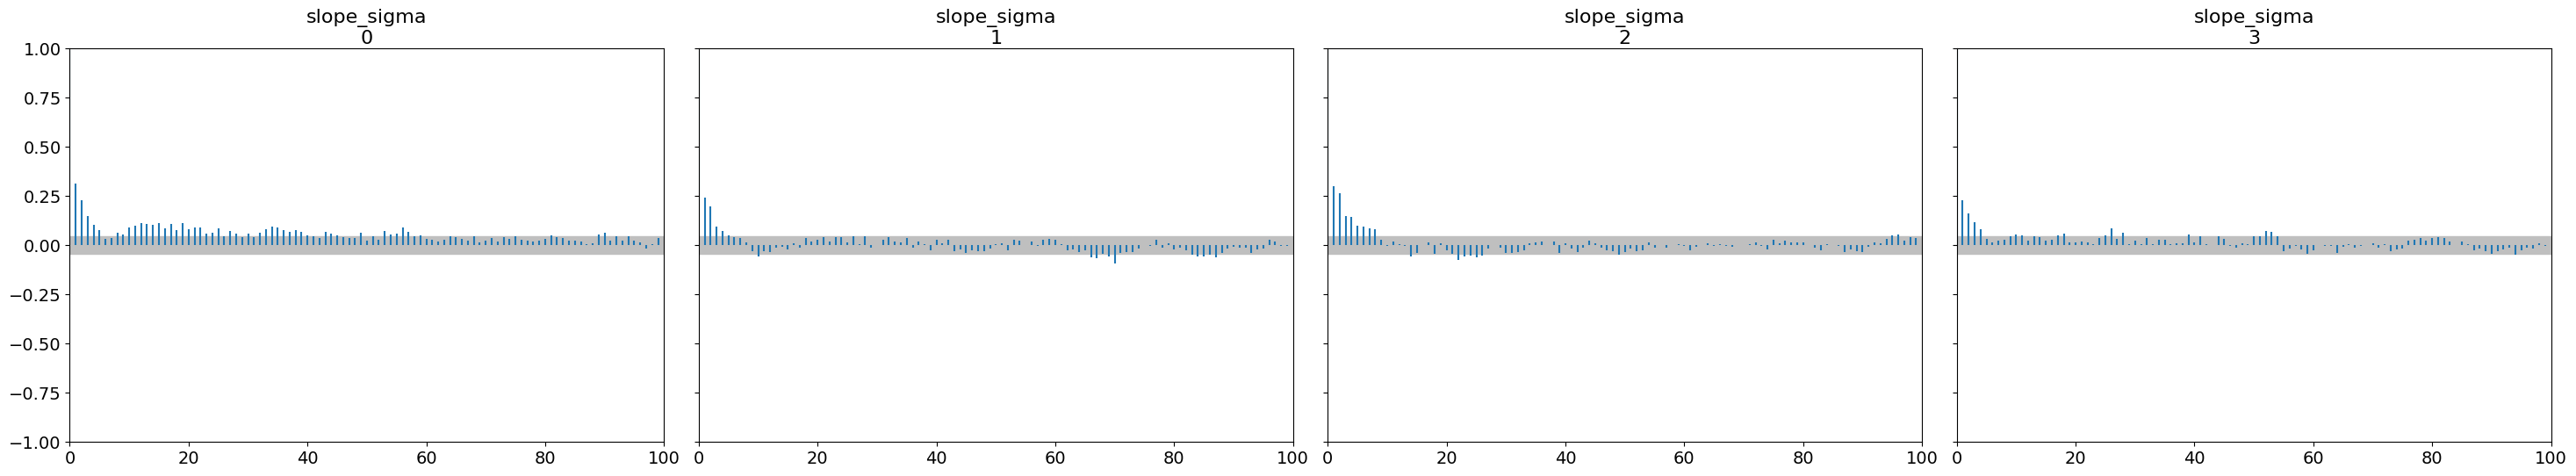

In [22]:
az.plot_autocorr(
    idata_centered,
    var_names=["slope_sigma"]
)

plt.tight_layout()
plt.show()

### Autocorrelation – Interpretation

The autocorrelation for `slope_sigma` decreases relatively quickly toward zero in most chains.

This suggests that strong serial dependence is not the main problem for this parameter.

However, the model still produced 351 divergences. Therefore, acceptable autocorrelation alone does not guarantee that the MCMC sampling is reliable.

The divergences suggest a deeper problem with the geometry of the centered hierarchical posterior.

### Why Does the Centered Model Cause Problems?

Hierarchical models can produce a funnel-shaped posterior geometry, especially when group-level standard deviations can become small.

In a centered parameterization, the species-specific parameters are directly tied to these scale parameters. This can create narrow and wide regions of the posterior that are difficult for the sampler to explore efficiently.

### AI Question

**What is Neal's funnel, why is it difficult for MCMC algorithms to sample, and how can a centered hierarchical parameterization create funnel-like geometry? Why do HMC and NUTS produce divergences in these regions?**

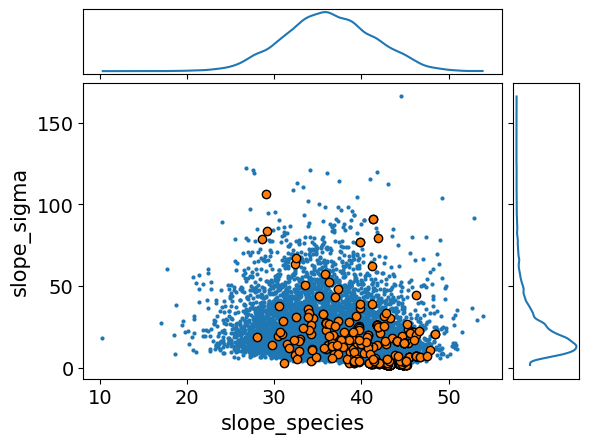

In [23]:
az.plot_pair(
    idata_centered,
    var_names=["slope_species", "slope_sigma"],
    coords={"species": "Chinstrap"},
    kind="scatter",
    divergences=True,
    marginals=True
)

plt.show()

### Divergences and Funnel Geometry – Interpretation

The divergent transitions are concentrated mainly in regions where `slope_sigma` is small.

When the group-level standard deviation becomes small, the species-specific slopes are forced into a narrow region of the posterior.

This creates a funnel-like geometry with both narrow and wide regions, which can be difficult for HMC and NUTS to explore efficiently.

The concentration of divergences in the narrow part of the posterior provides evidence that the centered parameterization is contributing to the sampling problem.

In [24]:
az.summary(
    idata_centered,
    var_names=[
        "intercept_species",
        "slope_species",
        "intercept_sigma",
        "slope_sigma",
        "sigma_hyperprior"
    ],
    hdi_prob=0.95
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept_species[Adelie],4069.743,63.132,3944.152,4188.596,2.295,1.252,765.0,368.0,1.01
intercept_species[Chinstrap],3924.482,45.258,3838.363,4016.574,0.857,0.723,2827.0,2013.0,1.00
intercept_species[Gentoo],4182.526,93.996,3990.400,4359.662,4.459,3.104,454.0,147.0,1.01
slope_species[Adelie],33.798,4.999,24.063,43.849,0.184,0.118,762.0,285.0,1.00
slope_species[Chinstrap],36.204,5.117,26.834,46.384,0.122,0.068,1801.0,2129.0,1.00
slope_species[Gentoo],54.607,5.350,44.860,65.521,0.245,0.144,478.0,180.0,1.01
intercept_sigma,309.266,258.296,23.980,805.635,5.691,5.755,482.0,144.0,1.01
slope_sigma,22.343,15.894,1.649,54.142,0.363,0.361,650.0,274.0,1.01
sigma_hyperprior,542.275,283.700,171.809,1103.885,4.349,5.320,1736.0,2806.0,1.00


### Centered Model Summary – Interpretation

The R-hat values are approximately 1.00–1.01, suggesting that the four chains are broadly consistent with each other.

However, some effective sample sizes, especially in the tails, are relatively low for parameters such as `intercept_sigma` and the Gentoo-specific parameters.

More importantly, the model produced 351 divergences.

Therefore, the apparently acceptable R-hat values are not sufficient to conclude that the centered model sampled the posterior reliably.

The combination of divergences, funnel-like geometry, and weaker tail ESS motivates a non-centered parameterization.

### Non-Centered Parameterization

We now reparameterize the hierarchical model without changing its theoretical structure.

Instead of sampling the species-specific intercepts and slopes directly from their population distributions, we first sample standard-normal offset variables.

The species-specific parameters are then constructed from the population mean, population standard deviation, and these offsets.

This often makes hierarchical posterior geometry easier for HMC and NUTS to explore.

### AI Question

**What is the non-centered parameterization, why does it represent the same hierarchical model, and how can it reduce funnel geometry and MCMC divergences compared with the centered parameterization?**

Output()

ERROR:pymc.stats.convergence:There were 355 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


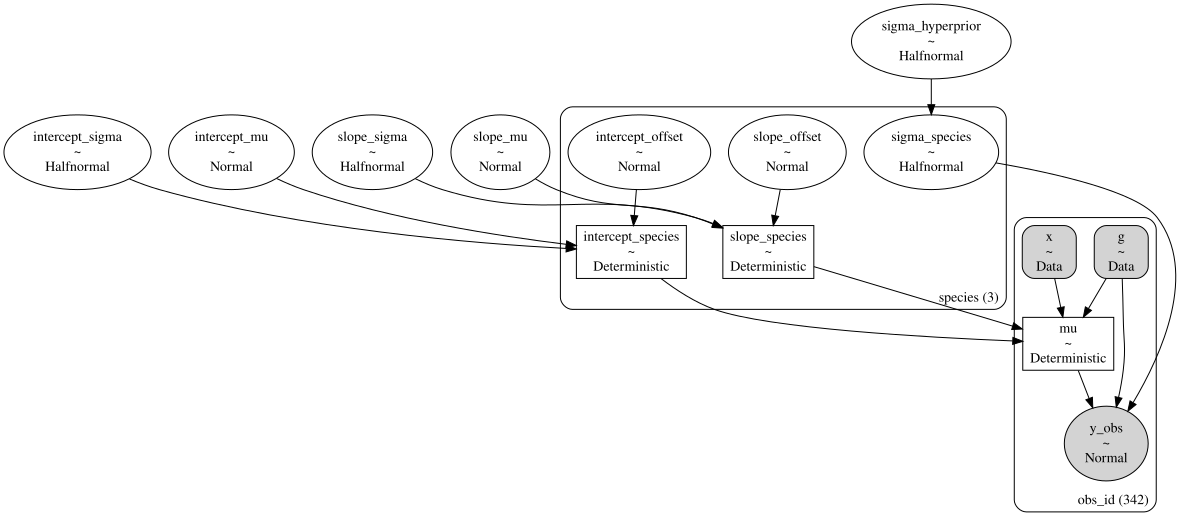

In [29]:
with pm.Model(coords=coords_h) as hierarchical_noncentered:

    # Hyperpriors
    intercept_mu = pm.Normal(
        "intercept_mu",
        mu=4200,
        sigma=1000
    )

    intercept_sigma = pm.HalfNormal(
        "intercept_sigma",
        sigma=1000
    )

    slope_mu = pm.Normal(
        "slope_mu",
        mu=50,
        sigma=50
    )

    slope_sigma = pm.HalfNormal(
        "slope_sigma",
        sigma=50
    )

    sigma_hyperprior = pm.HalfNormal(
        "sigma_hyperprior",
        sigma=1000
    )

    # Non-centered species-specific parameters
    intercept_offset = pm.Normal(
        "intercept_offset",
        mu=0,
        sigma=1,
        dims="species"
    )

    slope_offset = pm.Normal(
        "slope_offset",
        mu=0,
        sigma=1,
        dims="species"
    )

    intercept_species = pm.Deterministic(
        "intercept_species",
        intercept_mu + intercept_offset * intercept_sigma,
        dims="species"
    )

    slope_species = pm.Deterministic(
        "slope_species",
        slope_mu + slope_offset * slope_sigma,
        dims="species"
    )

    sigma_species = pm.HalfNormal(
        "sigma_species",
        sigma=sigma_hyperprior,
        dims="species"
    )

    x = pm.Data(
        "x",
        data["flipper_centered"].values,
        dims="obs_id"
    )

    g = pm.Data(
        "g",
        species_idx,
        dims="obs_id"
    )

    mu = pm.Deterministic(
        "mu",
        intercept_species[g] + slope_species[g] * x,
        dims="obs_id"
    )

    pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma_species[g],
        observed=data["body_mass_g"].values,
        dims="obs_id"
    )

    idata_noncentered = pm.sample(
        2000,
        tune=1000,
        chains=4,
        random_seed=42,
        idata_kwargs={"log_likelihood": True}
    )

pm.model_to_graphviz(hierarchical_noncentered)

### Non-Centered Model – Interpretation

The non-centered parameterization produced 355 divergences, compared with 351 divergences in the centered model.

Therefore, in this dataset, the non-centered parameterization did not improve the sampling performance.

This shows that reparameterization does not necessarily eliminate MCMC difficulties in every hierarchical model.

Because both models still contain many divergences, their posterior estimates should be interpreted cautiously.

### Section 5 Summary

The hierarchical models allowed the relationship between flipper length and body mass to vary across penguin species while sharing information between groups through common hyperpriors.

The centered model produced 351 divergences, indicating serious difficulties in the MCMC sampling.

Diagnostic plots showed that these divergences were associated with funnel-like posterior geometry.

A non-centered parameterization was then used for the species-specific intercepts and slopes. However, it produced 355 divergences and therefore did not improve sampling for this dataset.

This comparison demonstrates that non-centered parameterization can be a useful strategy for hierarchical models, but it is not guaranteed to solve sampling problems in every case.

Because both hierarchical models contain many divergences, their numerical posterior estimates should be interpreted cautiously.

## 6. Classical vs Bayesian Comparison and Conclusions

We now compare the classical and Bayesian regression approaches used in this notebook.

The simple OLS and Bayesian regression models produced very similar estimates for the relationship between flipper length and body mass.

The species-based analyses showed that the relationship differs across species. However, the hierarchical Bayesian models also demonstrated important MCMC sampling difficulties that must be considered before interpreting their posterior estimates.

### AI Question

**How should classical confidence intervals and Bayesian credible intervals be compared, and what are the main differences between interpreting an OLS regression coefficient and a Bayesian posterior distribution for the same coefficient?**

In [28]:
ols_slope = ols_model.params["flipper_centered"]
ols_ci = ols_model.conf_int().loc["flipper_centered"]

bayes_slope = float(
    idata_bayes.posterior["slope"].mean().values
)

bayes_hdi = (
    az.hdi(
        idata_bayes.posterior["slope"],
        hdi_prob=0.95
    )["slope"]
    .values
)

comparison_table = pd.DataFrame({
    "Method": [
        "Classical OLS",
        "Bayesian Regression"
    ],
    "Slope Estimate": [
        ols_slope,
        bayes_slope
    ],
    "Lower 95% Interval": [
        ols_ci[0],
        bayes_hdi[0]
    ],
    "Upper 95% Interval": [
        ols_ci[1],
        bayes_hdi[1]
    ],
    "Interval Type": [
        "95% Confidence Interval",
        "95% HDI"
    ]
})

comparison_table.round(2)

,Method,Slope Estimate,Lower 95% Interval,Upper 95% Interval,Interval Type
0,Classical OLS,49.69,46.7,52.67,95% Confidence Interval
1,Bayesian Regression,49.66,46.7,52.62,95% HDI


### Classical vs Bayesian Regression – Interpretation

The classical and Bayesian regression models produce almost identical slope estimates.

The OLS slope estimate is 49.69 g per millimeter, while the Bayesian posterior mean is 49.66 g per millimeter.

The corresponding 95% intervals are also very similar.

However, their interpretations are different. The classical 95% confidence interval is based on repeated-sampling properties of the estimation procedure, while the Bayesian 95% HDI describes the range containing 95% of the posterior probability for the slope.

The close agreement between the two approaches suggests that, for this dataset and the weakly informative priors used here, the observed data dominate the estimation of the slope.

### Final Conclusions and Limitations

The Palmer Penguins data show a strong positive relationship between flipper length and body mass.

The classical OLS model and the simple Bayesian regression model produced almost identical slope estimates and very similar 95% intervals. The Bayesian model also showed good MCMC diagnostics, with well-mixed chains, high effective sample sizes, R-hat values close to 1, and no divergences.

The exploratory analysis and the classical species regression showed that species plays an important role in the relationship between flipper length and body mass. In particular, the relationship is not identical across all three species.

A hierarchical Bayesian model was therefore used to allow species-specific intercepts and slopes while sharing information across species. However, both the centered and non-centered versions produced many divergent transitions. Therefore, the posterior estimates from the hierarchical models should not be treated as fully reliable.

This analysis has several limitations. The dataset is observational, so the regression results describe associations rather than causal effects. Only flipper length and species were considered, although other variables such as sex or bill measurements may also help explain body mass. In addition, the hierarchical model contains only three species, which provides limited information for estimating population-level variation between groups.

Overall, the simple classical and Bayesian regressions gave consistent results, while the hierarchical analysis demonstrated both the flexibility of Bayesian modeling and the importance of carefully checking MCMC diagnostics before interpreting posterior estimates.